# LightGBM — Pipeline complet (split clusters + SHAP + comparaison Global vs Physique)

**Notebook** contient  :
-(comparaison features globales `X` vs features physiques `X_physical`, splits construits par `qcut`),

- split issu de `clustering_stratifie.ipynb` (`idx_train.npy` / `idx_test.npy` / `stratum_final`), sélection de features par SHAP, ré-entraînement sur les top features, et diagnostics avancés (overfit, gains vs baseline, importance consensus).

In [151]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import lightgbm as lgb
import shap

ROOT = Path().resolve().parent.parent
DATA_PROCESSED = ROOT / "data" / "processed"

RANDOM_STATE = 42
N_TOP_FEATURES = 30

## 1. Chargement des données et du split (issu de `clustering_stratifie.ipynb`)

In [152]:
X_filtered = pd.read_parquet(DATA_PROCESSED / "X.parquet")
Y_filtered = pd.read_parquet(DATA_PROCESSED / "Y.parquet")
X_physical_filtered = pd.read_parquet(DATA_PROCESSED / "X_physical_engineered.parquet")

idx_train = np.load(DATA_PROCESSED / "idx_train.npy")
idx_test = np.load(DATA_PROCESSED / "idx_test.npy")

labels = pd.read_parquet(DATA_PROCESSED / "cluster_labels.parquet")
stratum_train = labels.iloc[idx_train]["stratum_final"]
TARGET    = 'out.electricity.total.energy_consumption..kwh'
print("X          :", X_filtered.shape)
print("X_physical :", X_physical_filtered.shape)
print("Y          :", Y_filtered.shape)
print("idx_train / idx_test :", idx_train.shape, idx_test.shape)

# X_physical est construit à partir de X.copy() (même index, même ordre de lignes) :
# les mêmes idx_train / idx_test s'appliquent donc directement aux deux jeux de features.
assert X_filtered.index.equals(X_physical_filtered.index), "X et X_physical n'ont pas le même index : les idx ne sont pas transposables tels quels."

X          : (549971, 107)
X_physical : (549971, 84)
Y          : (549971, 5)
idx_train / idx_test : (439976,) (109995,)


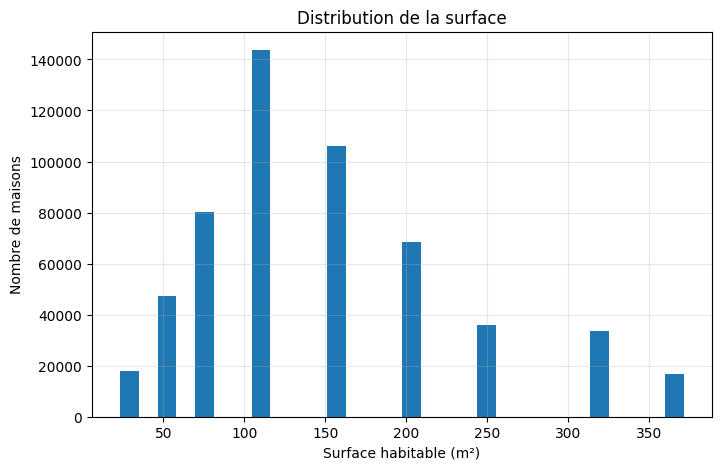

In [153]:
plt.figure(figsize=(8,5))

plt.hist(
    X_filtered["in.geometry_floor_area"],
    bins=30
)

plt.xlabel("Surface habitable (m²)")
plt.ylabel("Nombre de maisons")
plt.title("Distribution de la surface")

plt.grid(alpha=0.3)
plt.show()

In [154]:
surface_max = 250


mask = X_filtered["in.geometry_floor_area"] < surface_max

X= X_filtered.loc[mask].reset_index(drop=True)
Y = Y_filtered.loc[mask].reset_index(drop=True)
X_physical = X_physical_filtered.loc[mask].reset_index(drop=True)
labels = labels.loc[mask]
X = X.reset_index(drop=True)
Y = Y.reset_index(drop=True)
X_physical = X_physical.reset_index(drop=True)

labels = labels.reset_index(drop=True)

print("Avant :", len(X_filtered))
print("Après :", len(X))
print("Maisons supprimées :", len(X_filtered) - len(X))


Avant : 549971
Après : 463559
Maisons supprimées : 86412


In [155]:
# ============================================================
# Chargement des données
# ============================================================

ROOT = Path().resolve().parent.parent
DATA_PROCESSED = ROOT / "data" / "processed"

X = pd.read_parquet(DATA_PROCESSED / "X.parquet")
Y = pd.read_parquet(DATA_PROCESSED / "Y.parquet")
X_physical = pd.read_parquet(DATA_PROCESSED / "X_physical_engineered.parquet")
meta = pd.read_parquet(DATA_PROCESSED / "metadata_clean.parquet")
labels = pd.read_parquet(DATA_PROCESSED / "cluster_labels.parquet")

TARGET = 'out.electricity.total.energy_consumption..kwh'


print("Avant filtrage :")
print("X          :", X.shape)
print("X_physical :", X_physical.shape)
print("Y          :", Y.shape)



# ============================================================
# Vérification des index
# ============================================================

assert X.index.equals(X_physical.index), \
    "X et X_physical n'ont pas le même index"

assert X.index.equals(meta.index), \
    "X et metadata n'ont pas le même index"



# ============================================================
# Filtre physique
# ============================================================

mask_physical = (
    (meta['in.geometry_building_type_recs'] == 'Single-Family Detached') &
    (X['in.geometry_stories'] == 1) &
    (meta['in.heating_fuel'] == 'Electricity') &
    (X['in.electric_vehicle_charger'] == 0) &
    (X['in.has_pool'] == 0) &
    (X['in.has_pv'] == 0)
)


X = X.loc[mask_physical]
Y = Y.loc[mask_physical]
X_physical = X_physical.loc[mask_physical]
labels = labels.loc[mask_physical]



print("\nAprès filtre physique :", len(X))



# ============================================================
# Filtre surface
# ============================================================

surface_max = 250

mask_surface = X["in.geometry_floor_area"] < surface_max


X = X.loc[mask_surface]
Y = Y.loc[mask_surface]
X_physical = X_physical.loc[mask_surface]
labels = labels.loc[mask_surface]



print("\nAprès filtre surface :", len(X))
print("Maisons supprimées au total :", 
      549971 - len(X))



# ============================================================
# Reset index après tous les filtres
# ============================================================

X = X.reset_index(drop=True)
Y = Y.reset_index(drop=True)
X_physical = X_physical.reset_index(drop=True)
labels = labels.reset_index(drop=True)



print("\n===== DATA FINALE =====")
print("X          :", X.shape)
print("X_physical :", X_physical.shape)
print("Y          :", Y.shape)
print("labels     :", labels.shape)



Avant filtrage :
X          : (549971, 107)
X_physical : (549971, 84)
Y          : (549971, 5)

Après filtre physique : 64062

Après filtre surface : 56506
Maisons supprimées au total : 493465

===== DATA FINALE =====
X          : (56506, 107)
X_physical : (56506, 84)
Y          : (56506, 5)
labels     : (56506, 9)


## 2. Fonctions réutilisables (split, baseline, SHAP, métriques, diagnostics)

In [156]:
def build_splits(X_data, Y_data, idx_train, idx_test, stratum_train, test_size=0.2, random_state=RANDOM_STATE):
    """Construit train_final / val / test à partir d'un split fixe (idx_train/idx_test)
    et d'une stratification déjà calculée (stratum_train) pour le sous-split val."""

    X_train = X_data.iloc[idx_train]
    X_test = X_data.iloc[idx_test]
    Y_train = Y_data.iloc[idx_train]
    Y_test = Y_data.iloc[idx_test]

    X_train_final, X_val, Y_train_final, Y_val, _, _ = train_test_split(
        X_train,
        Y_train,
        stratum_train,
        test_size=test_size,
        random_state=random_state,
        stratify=stratum_train
    )

    total = len(X_train_final) + len(X_val) + len(X_test)
    print(f"Train : {X_train_final.shape} ({len(X_train_final)/total:.1%})")
    print(f"Val   : {X_val.shape} ({len(X_val)/total:.1%})")
    print(f"Test  : {X_test.shape} ({len(X_test)/total:.1%})")

    return X_train_final, X_val, X_test, Y_train_final, Y_val, Y_test



In [157]:
def dummy_baseline(Y_train_final, Y_test, target=TARGET):
    """Baseline naïve : prédiction = médiane du train pour une seule cible."""

    median_value = Y_train_final[target].median()

    y_pred = np.full(len(Y_test), median_value)

    results_dummy = {
        "RMSE": np.sqrt(mean_squared_error(Y_test[target], y_pred)),
        "MAE": mean_absolute_error(Y_test[target], y_pred),
        "R2": r2_score(Y_test[target], y_pred)
    }

    return pd.DataFrame([results_dummy], index=[target])

In [158]:

def train_with_shap_selection(
    X_train_final, X_val, X_test,
    Y_train_final, Y_val,
    target=TARGET,
    n_top_features=N_TOP_FEATURES,
    random_state=RANDOM_STATE
):
    """
    Entraîne un LightGBM sur toutes les features,
    calcule l'importance SHAP,
    sélectionne les meilleures features,
    puis ré-entraîne un modèle final allégé.
    """

    print(f"\n========== INITIAL MODEL {target} ==========")

    # ============================
    # 1) Modèle initial
    # ============================

    model = lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=63,
        random_state=random_state,
        n_jobs=-1
    )

    model.fit(
        X_train_final,
        Y_train_final[target],
        eval_set=[(X_val, Y_val[target])],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )

    prediction = model.predict(X_test)


    # ============================
    # 2) SHAP feature importance
    # ============================

    print("\nCalcul SHAP...")

    explainer = shap.TreeExplainer(model)

    # échantillon pour accélérer le calcul SHAP
    X_shap = X_train_final.sample(
        min(20000, len(X_train_final)),
        random_state=random_state
    )

    shap_values = explainer.shap_values(X_shap)

    shap_importance = np.abs(shap_values).mean(axis=0)

    importance_df = pd.DataFrame({
        "feature": X_train_final.columns,
        "importance": shap_importance
    }).sort_values(
        "importance",
        ascending=False
    )

    top_features = importance_df["feature"].head(n_top_features).values


    # ============================
    # 3) Modèle final réduit
    # ============================

    print("\n========== FINAL MODEL ==========")

    X_tr = X_train_final[top_features]
    X_vl = X_val[top_features]
    X_te = X_test[top_features]

    final_model = lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=63,
        random_state=random_state,
        n_jobs=-1
    )

    final_model.fit(
        X_tr,
        Y_train_final[target],
        eval_set=[(X_vl, Y_val[target])],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )

    final_prediction = final_model.predict(X_te)


    return {
        "model": model,
        "prediction": prediction,
        "importance_df": importance_df,
        "top_features": top_features,
        "final_model": final_model,
        "final_prediction": final_prediction
    }

In [159]:
def compute_metrics(Y_test, y_pred, target=TARGET):
    """
    Calcule RMSE, MAE, R2 et les erreurs relatives
    pour une seule cible.
    """

    y_true = Y_test[target]

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mean_target = y_true.mean()

    results = {
        "Mean": mean_target,
        "RMSE": rmse,
        "MAE": mae,
        "RMSE (%)": 100 * rmse / mean_target,
        "MAE (%)": 100 * mae / mean_target,
        "R2": r2_score(y_true, y_pred)
    }

    return pd.DataFrame([results], index=[target])

In [160]:
def overfit_gap(final_model,X_train_final,Y_train_final,Y_test,final_prediction,top_features,target=TARGET):
    """
    Calcule l'écart R2 train/test pour détecter le sur-apprentissage.
    """

    # prédictions train avec les features sélectionnées
    y_train_pred = final_model.predict(
        X_train_final[top_features]
    )

    # prédictions test
    y_test_pred = final_prediction

    train_r2 = r2_score(
        Y_train_final[target],
        y_train_pred
    )

    test_r2 = r2_score(
        Y_test[target],
        y_test_pred
    )

    results = {
        "Train_R2": train_r2,
        "Test_R2": test_r2,
        "Gap": train_r2 - test_r2
    }

    return pd.DataFrame([results], index=[target])

In [161]:
def feature_importance(model, X_train_final, n_top=107):
    """
    Retourne les n features les plus importantes
    pour un modèle LightGBM unique.
    """

    importance_df = pd.DataFrame({
        "Variable": X_train_final.columns,
        "Importance": model.feature_importances_
    })

    importance_df = importance_df.sort_values(
        "Importance",
        ascending=False
    ).reset_index(drop=True)

    return importance_df.head(n_top)

In [162]:
def gain_vs_dummy(df_dummy, df_metrics, target=TARGET):
    """
    Compare une baseline naïve (médiane) avec le modèle LightGBM final
    pour une seule cible.
    """

    comparison = pd.DataFrame(index=[target])

    comparison["Dummy_RMSE"] = df_dummy.loc[target, "RMSE"]
    comparison["Dummy_MAE"] = df_dummy.loc[target, "MAE"]
    comparison["Dummy_R2"] = df_dummy.loc[target, "R2"]

    comparison["LGBM_RMSE"] = df_metrics.loc[target, "RMSE"]
    comparison["LGBM_MAE"] = df_metrics.loc[target, "MAE"]
    comparison["LGBM_R2"] = df_metrics.loc[target, "R2"]

    comparison["Gain_RMSE_%"] = (
        (comparison["Dummy_RMSE"] - comparison["LGBM_RMSE"])
        / comparison["Dummy_RMSE"]
        * 100
    )

    comparison["Gain_MAE_%"] = (
        (comparison["Dummy_MAE"] - comparison["LGBM_MAE"])
        / comparison["Dummy_MAE"]
        * 100
    )

    comparison["Gain_R2"] = (
        comparison["LGBM_R2"] - comparison["Dummy_R2"]
    )

    return comparison

## 3. Exécution — Features globales (`X`)

In [164]:
X_train_final_g, X_val_g, X_test_g, Y_train_final_g, Y_val_g, Y_test_g = build_splits(
    X, Y, idx_train, idx_test, stratum_train
)

IndexError: positional indexers are out-of-bounds

In [ ]:
df_dummy_global = dummy_baseline(Y_train_final_g, Y_test_g, TARGET)
df_dummy_global

,RMSE,MAE,R2
out.electricity.total.energy_consumption..kwh,7556.489347,5231.71276,-0.053513


In [ ]:
out_global = train_with_shap_selection(
    X_train_final_g, X_val_g, X_test_g, Y_train_final_g, Y_val_g, TARGET
)


========== INITIAL MODEL out.electricity.total.energy_consumption..kwh ==========
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,013739 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1312
[LightGBM] [Info] Number of data points in the train set: 296677, number of used features: 107
[LightGBM] [Info] Start training from score 10540,108994

Calcul SHAP...

========== FINAL MODEL ==========
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,006903 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1003
[LightGBM] [Info] Number of data points in the train set: 296677, number of used features: 30
[LightGBM] [Info] Start training from score 10540,108994


In [ ]:
df_metrics_global = compute_metrics(
    Y_test_g,
    out_global["final_prediction"],
    TARGET
)
df_metrics_global.round(2)

,Mean,RMSE,MAE,RMSE (%),MAE (%),R2
out.electricity.total.energy_consumption..kwh,10564.94,2932.34,1535.32,27.76,14.53,0.84


In [ ]:
df_overfit_global = overfit_gap(
    final_model=out_global["final_model"],
    X_train_final=X_train_final_g,
    Y_train_final=Y_train_final_g,
    Y_test=Y_test_g,
    final_prediction=out_global["final_prediction"],
    top_features=out_global["top_features"],
    target=TARGET
)

df_overfit_global

,Train_R2,Test_R2,Gap
out.electricity.total.energy_consumption..kwh,0.889654,0.841354,0.048299


In [ ]:
importance_global = feature_importance(
    out_global["final_model"],
    X_train_final_g[out_global["top_features"]],
    n_top=20
)

importance_global

,Variable,Importance
0,in.weather_file_latitude,8318
1,in.weather_file_longitude,5929
2,in.electric_panel_breaker_space_total_count,5275
3,in.air_leakage_to_outside_ach50,3920
4,in.geometry_floor_area,3458
5,in.heating_setpoint,2878
6,in.water_heater_efficiency,2803
7,in.electric_panel_service_rating..a,2559
8,in.vintage,2438
9,in.plug_loads,2361


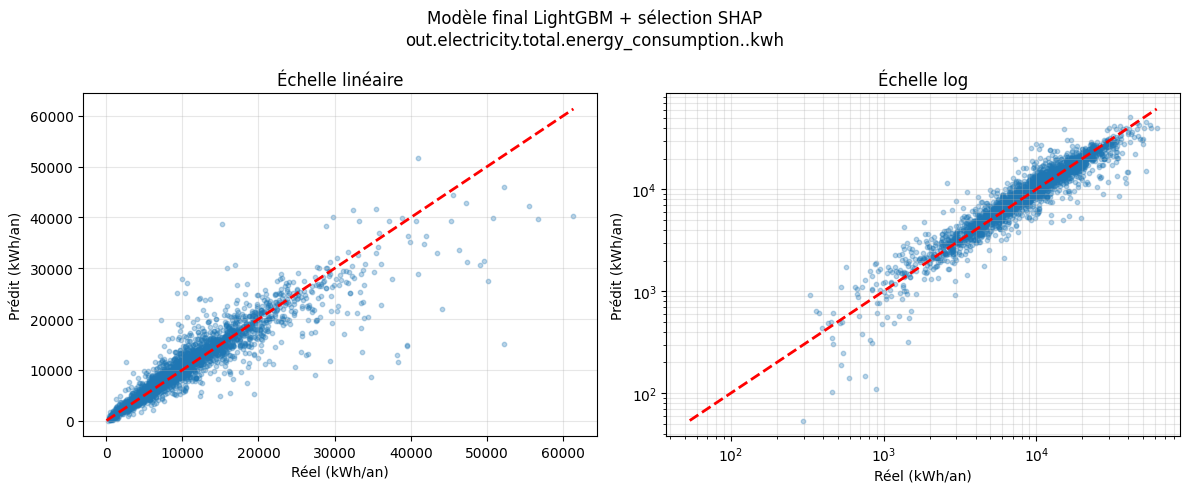

In [ ]:
#============================================================
# Scatter réel vs prédit — linéaire et log
# MODÈLE FINAL (post-sélection SHAP)
#============================================================

rng = np.random.default_rng(RANDOM_STATE)
n_points = 3000

target = TARGET

# Vraies valeurs et prédictions du modèle final
y_true = Y_test_g[target].reset_index(drop=True)
y_pred = pd.Series(out_global["final_prediction"]).reset_index(drop=True)


# ==========================
# Échantillonnage
# ==========================

n = min(n_points, len(y_true))

sample = rng.choice(len(y_true),size=n,replace=False)

y_true_s = y_true.iloc[sample]
y_pred_s = y_pred.iloc[sample]


# ==========================
# Suppression valeurs <= 0
# (nécessaire pour l'échelle log)
# ==========================

mask = (y_true_s > 0) & (y_pred_s > 0)

y_true_s = y_true_s[mask]
y_pred_s = y_pred_s[mask]


min_val = min(y_true_s.min(),y_pred_s.min())

max_val = max(y_true_s.max(),y_pred_s.max())


# ==========================
# Graphiques
# ==========================

fig, axes = plt.subplots(1,2,figsize=(12, 5))


# ---- Linéaire ----

axes[0].scatter(y_true_s,y_pred_s,alpha=0.3,s=10)
axes[0].plot([min_val, max_val],[min_val, max_val],"r--",linewidth=2)
axes[0].set_title("Échelle linéaire")
axes[0].set_xlabel("Réel (kWh/an)")
axes[0].set_ylabel("Prédit (kWh/an)")
axes[0].grid(alpha=0.3)



# ---- Log ----

axes[1].scatter(y_true_s,y_pred_s,alpha=0.3,s=10)
axes[1].plot([min_val, max_val],[min_val, max_val],"r--",linewidth=2)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Échelle log")
axes[1].set_xlabel("Réel (kWh/an)")
axes[1].set_ylabel("Prédit (kWh/an)")
axes[1].grid( alpha=0.3,which="both")


plt.suptitle(f"Modèle final LightGBM + sélection SHAP\n{target}")
plt.tight_layout()
plt.savefig(f"scatter_real_pred_{target}.png",dpi=300,bbox_inches="tight")
plt.show()

## 4. Exécution — Features physiques (`X_physical`)

Même split (`idx_train` / `idx_test` / `stratum_final`), mêmes fonctions, appliqués à `X_physical` pour une comparaison strictement équivalente.

In [ ]:
X_train_final_p, X_val_p, X_test_p, Y_train_final_p, Y_val_p, Y_test_p = build_splits(
    X_physical, Y, idx_train, idx_test, stratum_train
)

Train : (296677, 84) (64.0%)
Val   : (74170, 84) (16.0%)
Test  : (92712, 84) (20.0%)


In [ ]:
df_dummy_physical = dummy_baseline(Y_train_final_p, Y_test_p, TARGET)
df_dummy_physical

,RMSE,MAE,R2
out.electricity.total.energy_consumption..kwh,7556.489347,5231.71276,-0.053513


In [ ]:
out_physical = train_with_shap_selection(
    X_train_final_p, X_val_p, X_test_p, Y_train_final_p, Y_val_p, TARGET
)


========== INITIAL MODEL out.electricity.total.energy_consumption..kwh ==========
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,010744 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1725
[LightGBM] [Info] Number of data points in the train set: 296677, number of used features: 84
[LightGBM] [Info] Start training from score 10540,108994

Calcul SHAP...

========== FINAL MODEL ==========
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,008239 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1291
[LightGBM] [Info] Number of data points in the train set: 296677, number of used features: 30
[LightGBM] [Info] Start training from score 10540,108994


In [ ]:

df_metrics_physical = compute_metrics(
    Y_test_g,
    out_physical["final_prediction"],
    TARGET
)
df_metrics_physical.round(2)

,Mean,RMSE,MAE,RMSE (%),MAE (%),R2
out.electricity.total.energy_consumption..kwh,10564.94,3178.04,1815.56,30.08,17.18,0.81


In [ ]:


df_overfit_physical = overfit_gap(
    final_model=out_physical["final_model"],
    X_train_final=X_train_final_p,
    Y_train_final=Y_train_final_p,
    Y_test=Y_test_p,
    final_prediction=out_physical["final_prediction"],
    top_features=out_physical["top_features"],
    target=TARGET
)

df_overfit_physical

,Train_R2,Test_R2,Gap
out.electricity.total.energy_consumption..kwh,0.865995,0.813655,0.05234


In [ ]:
importance_physical = feature_importance(
    out_physical["final_model"],
    X_train_final_p[out_physical["top_features"]],
    n_top=82
)

importance_physical

,Variable,Importance
0,in.weather_file_latitude,7580
1,in.weather_file_longitude,5354
2,in.electric_panel_breaker_space_total_count,5147
3,in.dhw_intensity,4105
4,in.thermal_envelope_index,3686
5,in.air_leakage_to_outside_ach50,3539
6,in.occupancy_intensity,3510
7,in.heating_setpoint,2494
8,in.vintage,2473
9,in.water_heater_efficiency,2402


## 5. Comparaison finale — Global vs Physique (même split, même méthodologie)

In [ ]:
final_comparison = pd.DataFrame({
    "R2_global": df_metrics_global["R2"],
    "R2_physical": df_metrics_physical["R2"],
    "RMSE_global": df_metrics_global["RMSE"],
    "RMSE_physical": df_metrics_physical["RMSE"],
    "Overfit_gap_global": df_overfit_global["Gap"],
    "Overfit_gap_physical": df_overfit_physical["Gap"],
})

final_comparison["delta_R2 (physical - global)"] = (
    final_comparison["R2_physical"] - final_comparison["R2_global"]
)
final_comparison["delta_RMSE (physical - global)"] = (
    final_comparison["RMSE_physical"] - final_comparison["RMSE_global"]
)

final_comparison.sort_values("delta_R2 (physical - global)", ascending=True).round(4)

,R2_global,R2_physical,RMSE_global,RMSE_physical,Overfit_gap_global,Overfit_gap_physical,delta_R2 (physical - global),delta_RMSE (physical - global)
out.electricity.total.energy_consumption..kwh,0.8414,0.8137,2932.3394,3178.0351,0.0483,0.0523,-0.0277,245.6957


## 6. Pistes d'optimisation restantes

1. **Optuna** n'est utilisé nulle part ici non plus : les hyperparamètres (`n_estimators=1000`, `learning_rate=0.05`, `num_leaves=63`) sont fixes et identiques pour les 5 cibles. Une recherche Optuna par cible (surtout `fuel_oil` et `propane`, qui ont le plus gros écart train/test) reste la prochaine étape logique.
2. **`fuel_oil` et `propane`** ont systématiquement le R² le plus bas et le `Gap` train/test le plus élevé (cf. section overfit) → cibles prioritaires pour un objectif Tweedie/Poisson ou une régularisation plus forte, plutôt que la MSE par défaut.
3. **`comparison_global` / `comparison_physical` / `final_comparison`** te permettent de trancher objectivement si `X_physical` apporte quelque chose sur ce split — regarde en particulier `delta_R2` pour chaque cible.